<a href="https://colab.research.google.com/github/shubham300701/AI-Meter-Remark-Classification/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Artificial Natural Network (ANN)**

Before Running of the Code, Please Upload Two Files in Google Colab Directory
- dataset.csv ( Columns Names "TEXT_REMARKS" and "ACTION_CATEGORY")
- .csv file need to upload for Newer Dataset (with only Two Columns i.e. "TEXT_REMARKS" and "ACTION_CATEGORY"


**Structure of 'dataset.csv':**

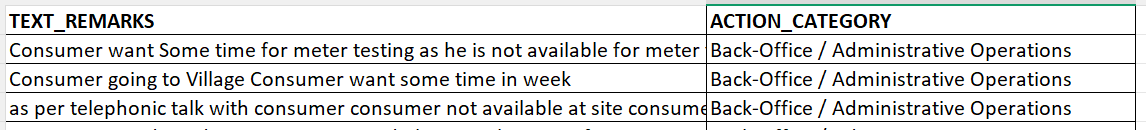

**Structure of newer dataset (in format of .csv):**

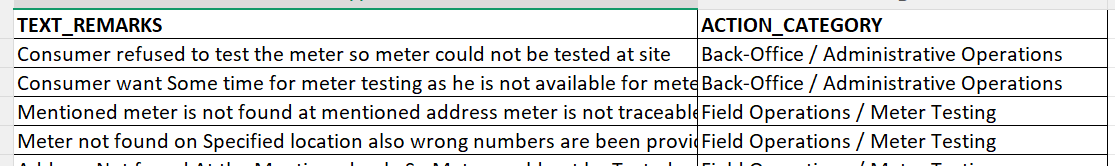


**Structure of Content of Google Colab:**

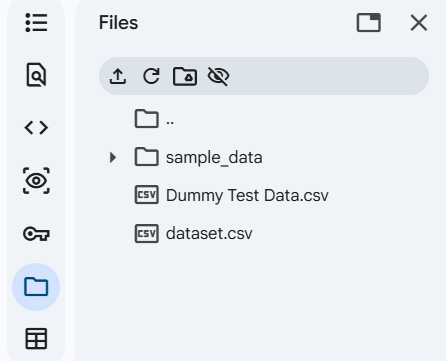

In [2]:
# =========================================================
# METER REMARK CLASSIFICATION USING ANN
# =========================================================

# =========================
# 1 IMPORT LIBRARIES
# =========================

import pandas as pd
import pickle
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# =========================
# 2 LOAD DATASET
# =========================

data = pd.read_csv("dataset.csv")

print("Dataset Loaded Successfully")

print(data.head())


# =========================
# 3 INPUT AND OUTPUT
# =========================

X = data['TEXT_REMARKS']

y = data['ACTION_CATEGORY']


# =========================
# 4 TF-IDF VECTORIZATION
# =========================

tfidf = TfidfVectorizer(
    stop_words='english',
    lowercase=True
)

X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF Completed")

print("Total Features:", X_tfidf.shape[1])


# =========================
# 5 LABEL ENCODING
# =========================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Convert into categorical
y_categorical = to_categorical(y_encoded)

print("\nLabel Encoding Completed")


# =========================
# 6 TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print("\nDataset Split Completed")


# =========================
# 7 BUILD ANN MODEL
# =========================

model = Sequential()

# Input Layer
model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Hidden Layer
model.add(Dense(
    64,
    activation='relu'
))

# Output Layer
model.add(Dense(
    y_categorical.shape[1],
    activation='softmax'
))

print("\nANN Model Created")


# =========================
# 8 COMPILE MODEL
# =========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Compilation Completed")


# =========================
# 9 TRAIN MODEL
# =========================

history = model.fit(
    X_train.toarray(),
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

print("\nANN Training Completed")


# =========================
# 10 MODEL PREDICTION
# =========================

y_pred_probs = model.predict(X_test.toarray())

y_pred = np.argmax(y_pred_probs, axis=1)

y_test_actual = np.argmax(y_test, axis=1)


# =========================
# 11 ACCURACY
# =========================

accuracy = accuracy_score(
    y_test_actual,
    y_pred
)

print("\n==============================")
print("ANN MODEL ACCURACY")
print("==============================")

print("Accuracy:", accuracy)


# =========================
# 12 CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_actual,
        y_pred
    )
)


# =========================
# 13 CONFUSION MATRIX
# =========================

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test_actual,
        y_pred
    )
)


# =========================
# 14 SAVE MODEL
# =========================

model.save("ann_meter_model.h5")

pickle.dump(tfidf, open("ann_tfidf.pkl", "wb"))

pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

print("\nANN Model Saved Successfully")


# =========================================================
# 15 LIVE PREDICTION FUNCTION
# =========================================================

def predict_department(text):

    # TF-IDF Transform
    text_vector = tfidf.transform([str(text)])

    # Predict Probability
    prediction_prob = model.predict(
        text_vector.toarray()
    )

    # Get Highest Probability Index
    predicted_index = np.argmax(prediction_prob)

    # Decode Department Name
    predicted_department = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    # Confidence Score
    confidence = np.max(prediction_prob) * 100

    return predicted_department, confidence


# =========================================================
# 16 BULK CSV PREDICTION
# =========================================================

input_file = input("\nEnter CSV File Name: ")

bulk_data = pd.read_csv(input_file)

print("Total Rows in Uploaded CSV:", len(bulk_data))

predicted_departments = []

confidence_scores = []

confidence_ranges = []

match_status = []


# =========================================================
# PREDICTION LOOP
# =========================================================

for index, row in bulk_data.iterrows():

    remark = row['TEXT_REMARKS']

    department, confidence = predict_department(remark)

    confidence = round(confidence, 2)

    predicted_departments.append(department)

    confidence_scores.append(confidence)

    # =========================================
    # CONFIDENCE RANGE
    # =========================================

    if confidence >= 90:

        confidence_ranges.append("100-90% Very High")

    elif confidence >= 75:

        confidence_ranges.append("90-75% High")

    elif confidence >= 50:

        confidence_ranges.append("75-50% Medium")

    else:

        confidence_ranges.append("Below 50% Low")

    # =========================================
    # MATCH STATUS
    # =========================================

    actual = str(row['ACTION_CATEGORY']).strip()

    predicted = str(department).strip()

    if actual == predicted:

        match_status.append("Correct")

    else:

        match_status.append("Wrong")


# =========================================================
# ADD OUTPUT COLUMNS
# =========================================================

bulk_data['PREDICTED_DEPARTMENT'] = predicted_departments

bulk_data['CONFIDENCE_SCORE'] = confidence_scores

bulk_data['CONFIDENCE_RANGE'] = confidence_ranges

bulk_data['MATCH_STATUS'] = match_status

bulk_data['IS_MATCH'] = (
    bulk_data['ACTION_CATEGORY']
    ==
    bulk_data['PREDICTED_DEPARTMENT']
)


# =========================================================
# SAVE OUTPUT CSV
# =========================================================

bulk_data.to_csv(
    "ANN_Predicted_Output.csv",
    index=False
)

print("\n====================================")
print("ANN PREDICTION COMPLETED")
print("====================================")

print("\nOutput File Saved Successfully")

Dataset Loaded Successfully
                                        TEXT_REMARKS  \
0  Consumer want Some time for meter testing as h...   
1  Consumer going to Village Consumer want some t...   
2  as per telephonic talk with consumer consumer ...   
3  No person at side and no response on said phon...   
4  No person at side and no response on said phon...   

                           ACTION_CATEGORY  
0  Back-Office / Administrative Operations  
1  Back-Office / Administrative Operations  
2  Back-Office / Administrative Operations  
3  Back-Office / Administrative Operations  
4  Back-Office / Administrative Operations  

TF-IDF Completed
Total Features: 862

Label Encoding Completed

Dataset Split Completed


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



ANN Model Created

Model Compilation Completed
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8591 - loss: 0.7183 - val_accuracy: 0.9675 - val_loss: 0.1513
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9811 - loss: 0.0994 - val_accuracy: 0.9885 - val_loss: 0.0546
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9932 - loss: 0.0413 - val_accuracy: 0.9927 - val_loss: 0.0390
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9958 - loss: 0.0252 - val_accuracy: 0.9916 - val_loss: 0.0333
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9961 - loss: 0.0206 - val_accuracy: 0.9916 - val_loss: 0.0332
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9974 - loss: 0.0166 - val_accuracy: 0.9916 - val_loss: 0.0333
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9976 - loss: 0.0152 - val_accuracy: 0.9885 - val_loss: 0.0357
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step -


ANN MODEL ACCURACY
Accuracy: 0.9899328859060402

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        46
           1       1.00      0.97      0.99        35
           2       1.00      1.00      1.00        32
           3       1.00      0.94      0.97        89
           4       0.99      0.99      0.99       337
           5       1.00      0.89      0.94         9
           6       0.99      1.00      1.00       644

    accuracy                           0.99      1192
   macro avg       0.99      0.97      0.98      1192
weighted avg       0.99      0.99      0.99      1192


Confusion Matrix:

[[ 46   0   0   0   0   0   0]
 [  0  34   0   0   1   0   0]
 [  0   0  32   0   0   0   0]
 [  3   0   0  84   1   0   1]
 [  0   0   0   0 334   0   3]
 [  0   0   0   0   1   8   0]
 [  0   0   0   0   2   0 642]]

ANN Model Saved Successfully

Enter CSV File Name: Dummy Test Data.csv
Total Rows in Uploa

**Files in Content After Running the code:**

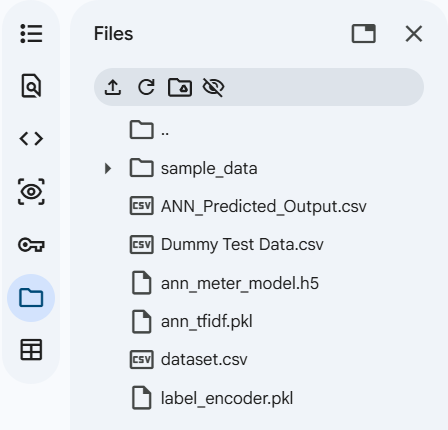

**Structure of "ANN_Predicted_Output":**
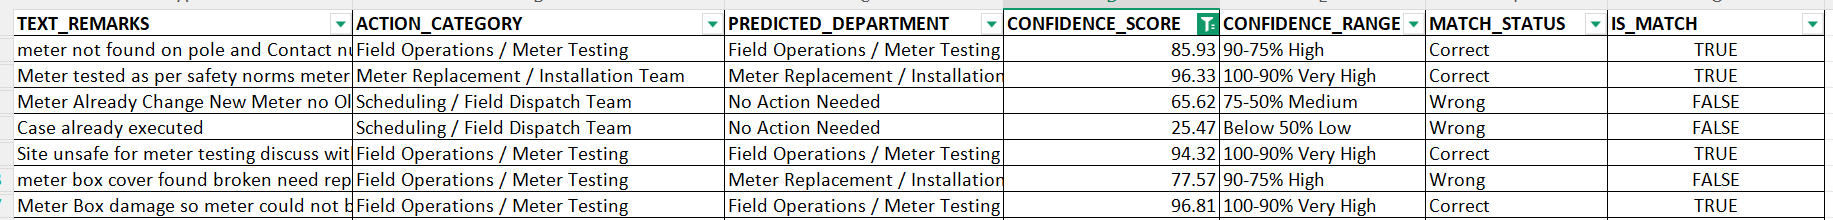

Link: https://colab.research.google.com/drive/1Qn21gSzQF39vjFIBBtnj5tGUt3bu1l1W?usp=sharing